# Trojan Detection Using Machine Learning and Deep Learning
Harvinder Dhillon
22150221

Comparing different algorithms to see which works best for detecting trojans in network traffic.

Dataset: 177,482 network traffic samples from Kaggle

GitHub: https://github.com/harvey1076/CMP7239-Trojan-Detection-

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D

import warnings
warnings.filterwarnings('ignore')

Dataset Description and Exploratory Data Analysis

### Part 1: BEFORE Preprocessing - Understanding the Raw Data

In [ ]:
# Load the raw dataset first
dataset_path = "/content/drive/MyDrive/Trojan_Detection.csv"
df_raw = pd.read_csv(dataset_path)
df_raw.columns = df_raw.columns.str.strip()

print("="*70)
print("SECTION 4.1: RAW DATASET ANALYSIS (BEFORE PREPROCESSING)")
print("="*70)
print(f"\nOriginal dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Features in raw data: {df_raw.shape[1] - 1} (plus 1 target variable)")

# Check missing values BEFORE
total_cells = df_raw.shape[0] * df_raw.shape[1]
missing_cells = df_raw.isnull().sum().sum()
missing_percentage = (missing_cells / total_cells) * 100

print(f"\nMissing Values Analysis:")
print(f"Total missing values: {missing_cells:,}")
print(f"Percentage of missing data: {missing_percentage:.2f}%")
print(f"Features with missing values: {(df_raw.isnull().sum() > 0).sum()}")

# Store BEFORE statistics
before_stats = {
    'total_samples': df_raw.shape[0],
    'total_features': df_raw.shape[1],
    'missing_values': missing_cells,
    'missing_percentage': missing_percentage
}

SECTION 4.1: RAW DATASET ANALYSIS (BEFORE PREPROCESSING)

Original dataset shape: 177482 rows × 86 columns
Features in raw data: 85 (plus 1 target variable)

Missing Values Analysis:
Total missing values: 0
Percentage of missing data: 0.00%
Features with missing values: 0


### Visualization 1: Class Distribution BEFORE Preprocessing

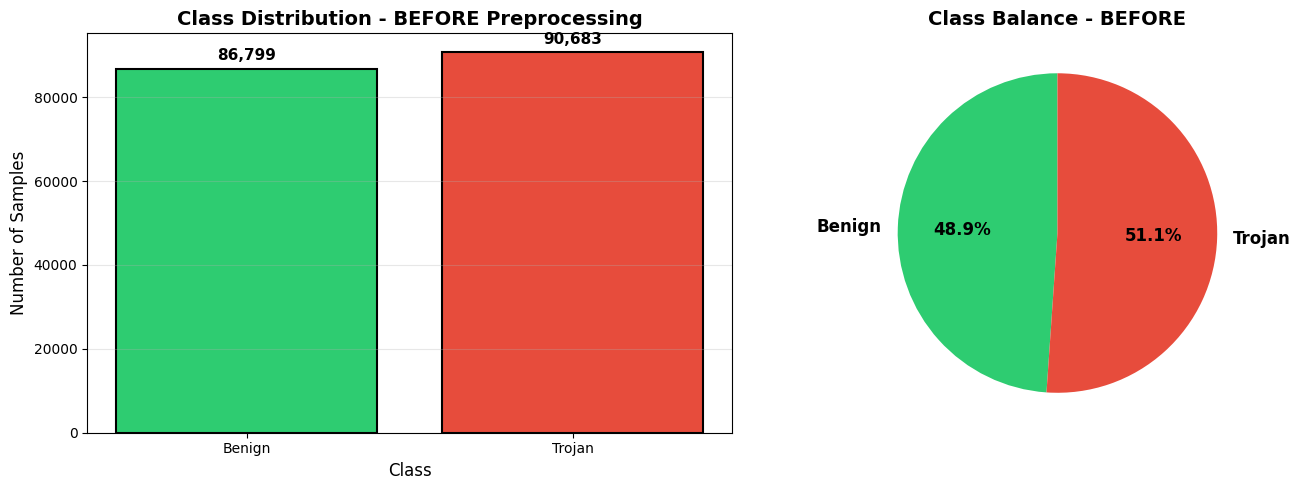


Class distribution BEFORE preprocessing:
Benign samples: 86,799 (48.9%)
Trojan samples: 90,683 (51.1%)
Balance ratio: 1.04:1


In [ ]:
# Class balance visualization - BEFORE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts_before = df_raw['Class'].value_counts()

# ADD THESE 2 LINES ← THIS IS WHAT YOU'RE MISSING!
benign_count = class_counts_before.get('Benign', 0)
trojan_count = class_counts_before.get('Trojan', 0)

# Bar chart
axes[0].bar(['Benign', 'Trojan'], [benign_count, trojan_count],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[0].set_title('Class Distribution - BEFORE Preprocessing', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Now these will work because benign_count and trojan_count exist!
axes[0].text(0, benign_count + 2000, f'{benign_count:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].text(1, trojan_count + 2000, f'{trojan_count:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie([benign_count, trojan_count], labels=['Benign', 'Trojan'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Balance - BEFORE', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/before_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass distribution BEFORE preprocessing:")
print(f"Benign samples: {benign_count:,} ({benign_count/len(df_raw)*100:.1f}%)")
print(f"Trojan samples: {trojan_count:,} ({trojan_count/len(df_raw)*100:.1f}%)")
print(f"Balance ratio: {trojan_count/benign_count:.2f}:1")

### Visualization 2: Missing Values BEFORE Preprocessing

In [ ]:
# Missing values by feature - BEFORE
missing_by_feature = df_raw.isnull().sum()
missing_features = missing_by_feature[missing_by_feature > 0].sort_values(ascending=False)

if len(missing_features) > 0:
    top_missing = missing_features.head(20)

    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(top_missing)), top_missing.values, color='#e74c3c', edgecolor='black')
    plt.yticks(range(len(top_missing)), top_missing.index, fontsize=10)
    plt.xlabel('Number of Missing Values', fontsize=12, fontweight='bold')
    plt.title('Top 20 Features with Missing Values - BEFORE Preprocessing', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_missing.values)):
        plt.text(val + (max(top_missing.values) * 0.02), i, f'{val:,}',
                va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/before_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nFeatures with most missing values:")
    for feat, count in top_missing.head(5).items():
        pct = (count / len(df_raw)) * 100
        print(f"  {feat}: {count:,} ({pct:.1f}%)")
else:
    print("\nNo missing values found in the raw dataset.")


No missing values found in the raw dataset.


## Data Preprocessing

Before training any models, I need to clean the dataset properly. The raw data has issues that would confuse the algorithms if I don't fix them first.

What I'm doing and why:
1. removing metadata
First i have removed IP addresses as this may cause data leakage and as model would just memorise the Ip instead of learning attack patterns, ports, timestamps which are irrelevant to detecting a trojan and Flow Ids. All of these features are unncessary and model should learn behaviour patterns such as packet size not specific identifiers.
2. removing features
removing features that are that are more than 95% similar to each other. Like two features that measure same things like, total bytes and packet average size. Therefore by doing this my dataset was then reduced from 85 features to 56.
3. Missing values but there is no missing values.
4. So all algorithms understand the data benign and trojan are converted to 0 and 1
5. Scaling data
I am using StandardScaler to normalise the features, as different features have different scales like packet size might be between 0-10,000 but duration is 0-100. Without using this algorithms look more at larger numbers as they are larger not due to their importance. Critical for neural networks which essentially works like a human brain.
6. Train split is 80% with 20% testing to even out the data in the most efficient way.

Some of these are critical for neural networks which are very sensitive to input ranges.

In [ ]:
# Preprocessing pipeline
df = df_raw.copy()

print("\n" + "="*70)
print("APPLYING PREPROCESSING STEPS")
print("="*70)

# Step 1: Drop metadata
metadata_cols = ['Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
                 'Source Port', 'Destination Port', 'Protocol', 'Fwd Header Length.1']
df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors='ignore')
print(f"\n✓ Step 1: Removed metadata columns")
print(f"  Features remaining: {df.shape[1]}")

# Step 2: Handle missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))
print(f"\n✓ Step 2: Handled missing values with median imputation")
print(f"  Missing values after: {df.isnull().sum().sum()}")

# Step 3: Encode target
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
X = df.drop('Class', axis=1)
y = df['Class']
print(f"\n✓ Step 3: Encoded target variable (Benign=0, Trojan=1)")
print(f"  Class distribution: {dict(y.value_counts())}")

# Step 4: Remove correlated features
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_before_corr = X.shape[1]
X = X.drop(columns=to_drop)
print(f"\n✓ Step 4: Removed highly correlated features (>95% threshold)")
print(f"  Features before: {X_before_corr}")
print(f"  Features after: {X.shape[1]}")
print(f"  Features removed: {len(to_drop)}")

# Step 5: Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n✓ Step 5: Split data into train/test sets (80/20)")
print(f"  Training samples: {X_train_raw.shape[0]:,}")
print(f"  Testing samples: {X_test_raw.shape[0]:,}")

# Step 6: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)
print(f"\n✓ Step 6: Scaled features using StandardScaler (mean=0, std=1)")

# Store AFTER statistics
after_stats = {
    'total_samples': X.shape[0],
    'total_features': X.shape[1],
    'missing_values': 0,
    'train_samples': X_train_raw.shape[0],
    'test_samples': X_test_raw.shape[0]
}

print("\n" + "="*70)
print("PREPROCESSING COMPLETE")
print("="*70)


APPLYING PREPROCESSING STEPS

✓ Step 1: Removed metadata columns
  Features remaining: 77

✓ Step 2: Handled missing values with median imputation
  Missing values after: 0

✓ Step 3: Encoded target variable (Benign=0, Trojan=1)
  Class distribution: {1: np.int64(90683), 0: np.int64(86799)}

✓ Step 4: Removed highly correlated features (>95% threshold)
  Features before: 76
  Features after: 56
  Features removed: 20

✓ Step 5: Split data into train/test sets (80/20)
  Training samples: 141,985
  Testing samples: 35,497

✓ Step 6: Scaled features using StandardScaler (mean=0, std=1)

PREPROCESSING COMPLETE


### Part 2: AFTER Preprocessing - Cleaned Dataset Analysis

In [ ]:
print("\n" + "="*70)
print("SECTION 4.2: CLEANED DATASET ANALYSIS (AFTER PREPROCESSING)")
print("="*70)
print(f"\nFinal dataset shape: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Missing values: {after_stats['missing_values']}")
print(f"Data completeness: 100.0%")
print(f"\nTrain-Test Split:")
print(f"  Training: {after_stats['train_samples']:,} samples (80%)")
print(f"  Testing: {after_stats['test_samples']:,} samples (20%)")


SECTION 4.2: CLEANED DATASET ANALYSIS (AFTER PREPROCESSING)

Final dataset shape: 177482 rows × 56 features
Missing values: 0
Data completeness: 100.0%

Train-Test Split:
  Training: 141,985 samples (80%)
  Testing: 35,497 samples (20%)


### Visualization 3: Class Distribution AFTER Preprocessing

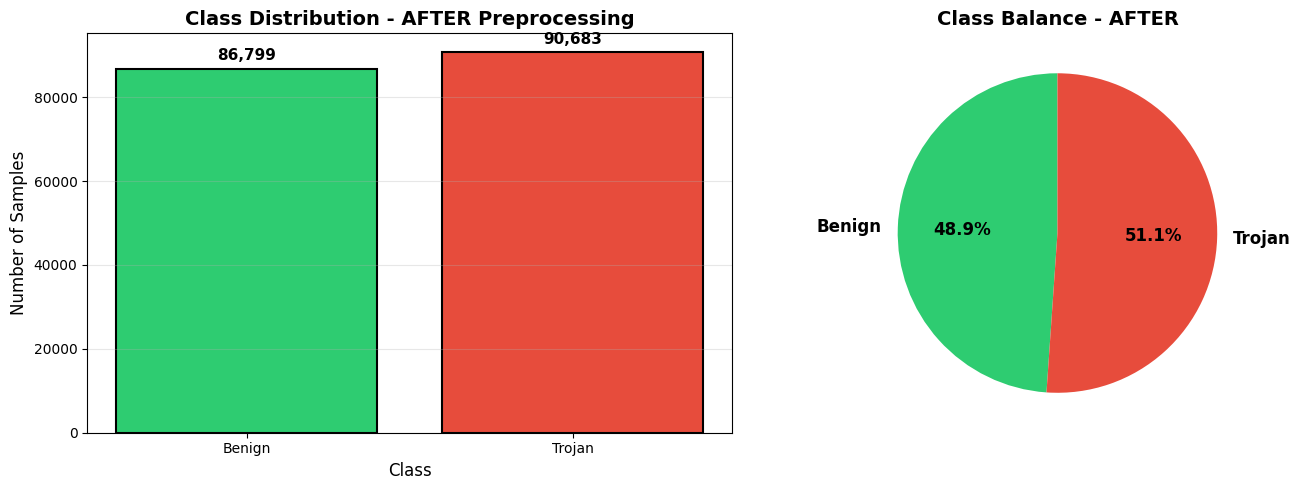


Class balance maintained after preprocessing:
Benign: 86,799 (48.9%)
Trojan: 90,683 (51.1%)


In [ ]:
# Class balance - AFTER
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts_after = y.value_counts().sort_index()
axes[0].bar(['Benign', 'Trojan'], [class_counts_after[0], class_counts_after[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
axes[0].set_title('Class Distribution - AFTER Preprocessing', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(class_counts_after):
    axes[0].text(i, count + 2000, f'{count:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(class_counts_after.values, labels=['Benign', 'Trojan'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Balance - AFTER', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/after_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass balance maintained after preprocessing:")
print(f"Benign: {class_counts_after[0]:,} ({class_counts_after[0]/len(y)*100:.1f}%)")
print(f"Trojan: {class_counts_after[1]:,} ({class_counts_after[1]/len(y)*100:.1f}%)")

### Visualization 4: BEFORE vs AFTER Comparison

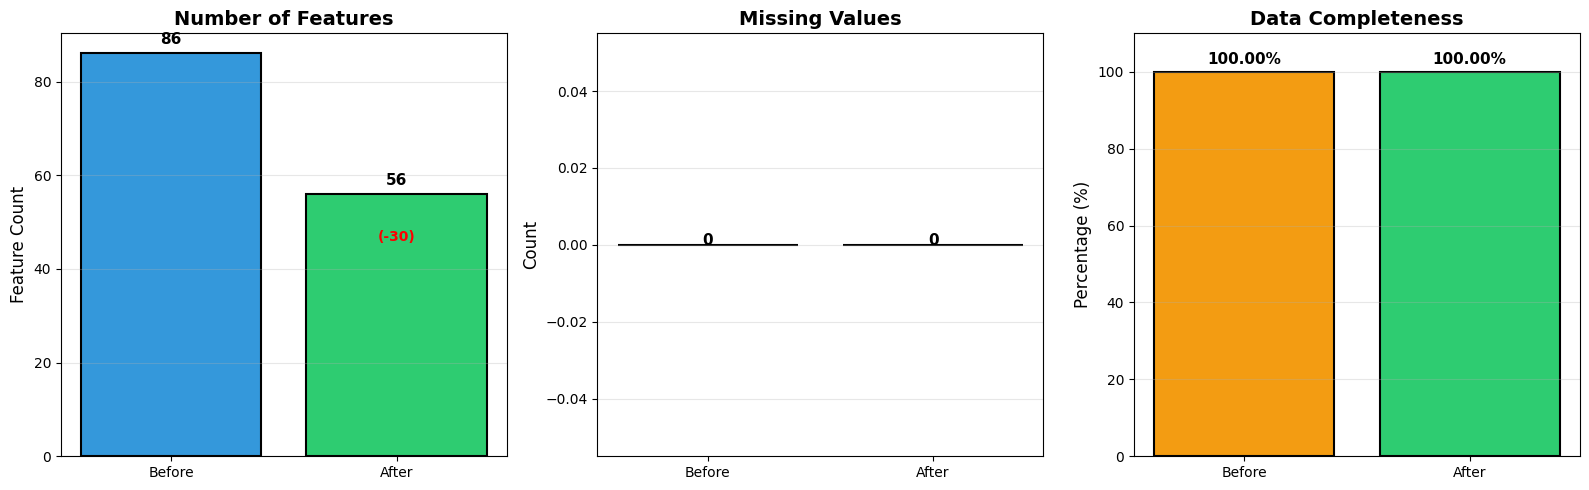


Summary of Changes:
  Features: 86 → 56 (30 removed)
  Missing values: 0 → 0 (all handled)
  Data quality: 100.00% → 100.0% (improved)


In [ ]:
# Comprehensive before/after comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categories = ['Before', 'After']
colors_comparison = ['#3498db', '#2ecc71']

# Subplot 1: Number of features
feature_counts = [before_stats['total_features'], after_stats['total_features']]
bars1 = axes[0].bar(categories, feature_counts, color=colors_comparison, edgecolor='black', linewidth=1.5)
axes[0].set_title('Number of Features', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Feature Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(feature_counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)
    if i == 1:
        reduction = before_stats['total_features'] - after_stats['total_features']
        axes[0].text(i, v - 10, f'(-{reduction})', ha='center', fontsize=10, color='red', fontweight='bold')

# Subplot 2: Missing values
missing_counts = [before_stats['missing_values'], after_stats['missing_values']]
bars2 = axes[1].bar(categories, missing_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Missing Values', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(missing_counts):
    axes[1].text(i, v + (max(missing_counts) * 0.05), f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Subplot 3: Data quality percentage
quality_before = 100 - before_stats['missing_percentage']
quality_after = 100.0
quality_scores = [quality_before, quality_after]
bars3 = axes[2].bar(categories, quality_scores, color=['#f39c12', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[2].set_title('Data Completeness', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Percentage (%)', fontsize=12)
axes[2].set_ylim([0, 110])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(quality_scores):
    axes[2].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/before_after_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary of Changes:")
print(f"  Features: {before_stats['total_features']} → {after_stats['total_features']} ({before_stats['total_features'] - after_stats['total_features']} removed)")
print(f"  Missing values: {before_stats['missing_values']:,} → {after_stats['missing_values']} (all handled)")
print(f"  Data quality: {quality_before:.2f}% → {quality_after:.1f}% (improved)")

In [ ]:
# Initialize storage for results and training times
results = {}
dl_histories = {}
training_times = {}

 Evaluation Metrics

Before running the algorithms, I need to explain what the metrics mean since they'll be used to evaluate every model.

### Accuracy

Accuracy measures the overall correctness of predictions:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Where:
- TP = True Positives (correctly identified trojans)
- TN = True Negatives (correctly identified benign traffic)
- FP = False Positives (benign traffic incorrectly flagged as trojan)
- FN = False Negatives (trojans incorrectly classified as benign)

I use accuracy as a baseline metric because the dataset has balanced classes (approximately 50% benign, 50% trojan), making it a meaningful overall measure (Maseer et al., 2021).

### Precision

Precision measures how many predicted trojans are actually trojans:

Precision = TP / (TP + FP)

For trojan detection, precision indicates the reliability of alerts. High precision means fewer false alarms, reducing wasted investigation time for security analysts (Alsharafi et al., 2023). Low precision would overwhelm security teams with false positives.

###  Recall (Sensitivity)

Recall measures how many actual trojans are detected:

Recall = TP / (TP + FN)

This is the most critical metric for cybersecurity applications. High recall ensures most threats are caught, while low recall means trojans slip through undetected (Zhang et al., 2023). Missing a real trojan (false negative) is more dangerous than a false alarm.

###  F1-Score

F1-score is the harmonic mean of precision and recall:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

The F1-score balances both precision and recall into a single metric. It penalizes extreme imbalance—a model with high precision but low recall (or vice versa) receives a lower F1-score (Rosay et al., 2020). This is important for trojan detection where we need both reliable alerts AND comprehensive threat coverage.

###  Confusion Matrix

The confusion matrix visualizes classification performance:
- Top-left (TN): Correctly predicted benign ✓
- Top-right (FP): Incorrectly predicted trojan (false alarm)
- Bottom-left (FN): Missed trojan (MOST DANGEROUS)
- Bottom-right (TP): Correctly predicted trojan ✓

For trojan detection, recall is most important since missing threats is worse than false alarms. However, too many false positives reduce analyst efficiency.

Implementation

### Visualization 5: Workflow Diagram

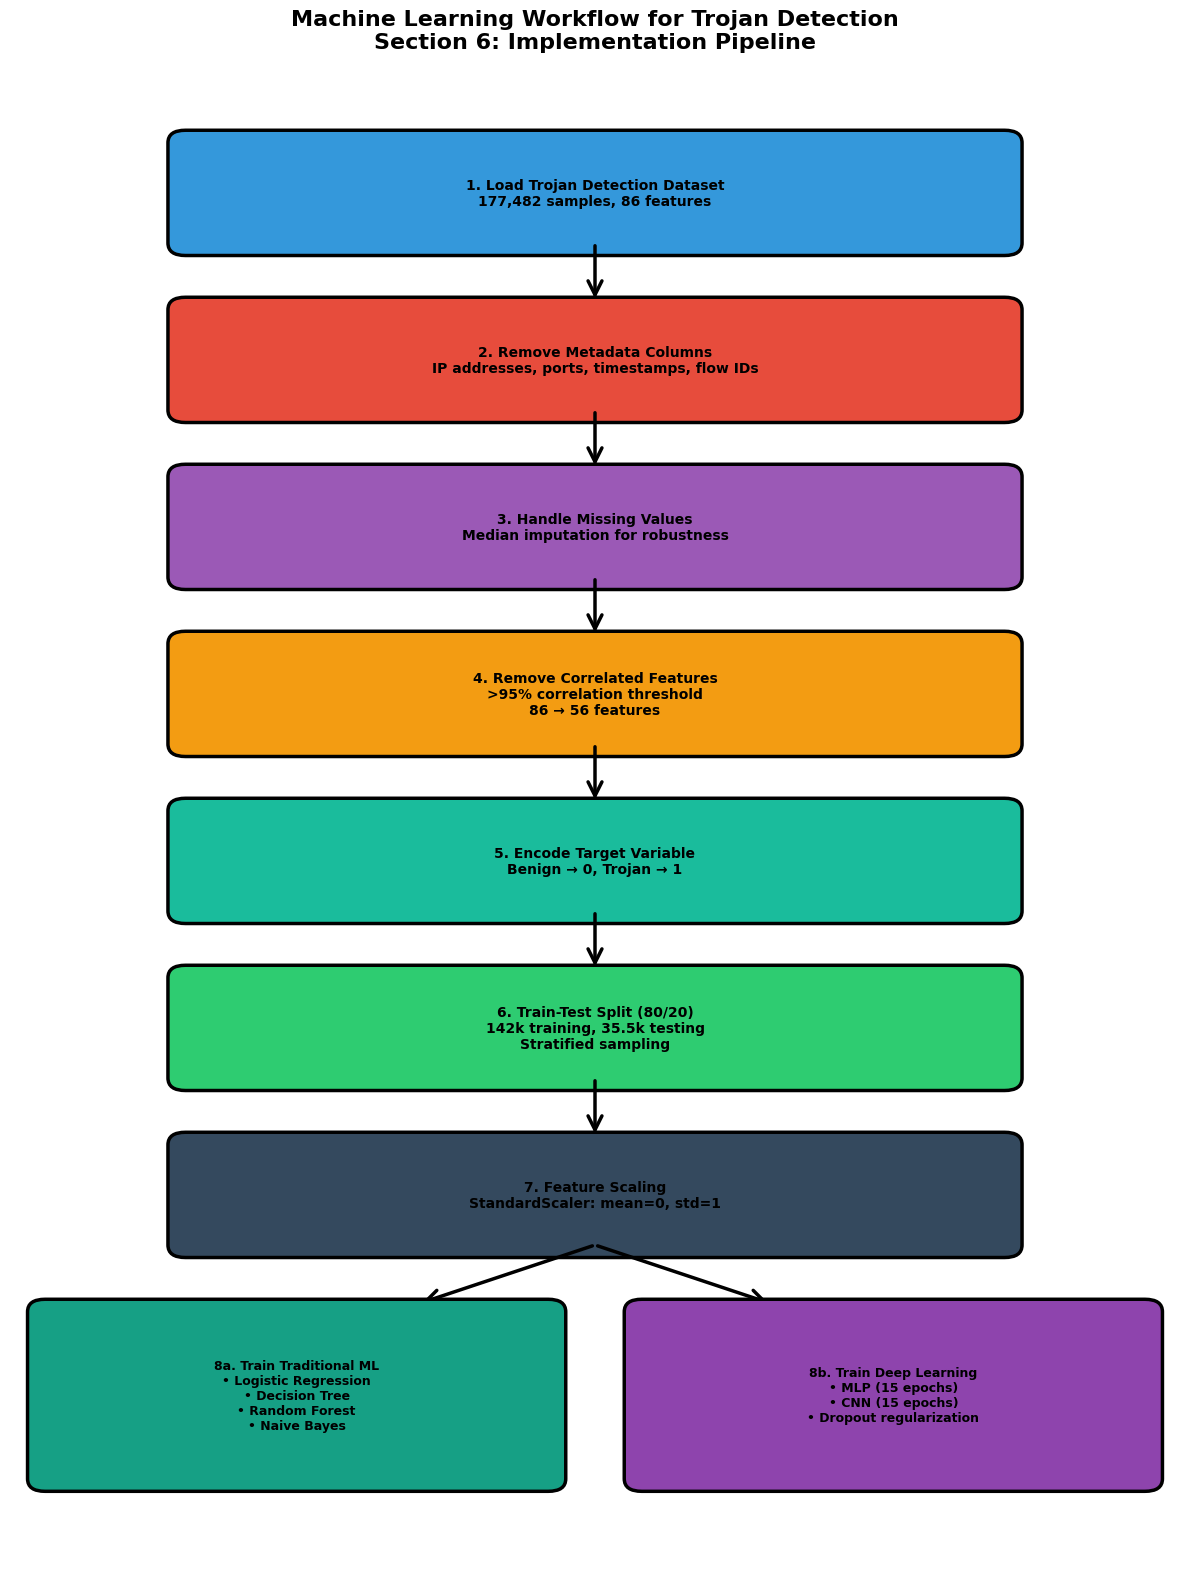

In [ ]:
# Create workflow diagram
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')

def add_box(x, y, width, height, text, color, fontsize=10):
    box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.15",
                          edgecolor='black', facecolor=color, linewidth=2.5)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->',
                            mutation_scale=25, linewidth=2.5, color='black')
    ax.add_patch(arrow)

# Workflow boxes
add_box(1.5, 16, 7, 1.2, '1. Load Trojan Detection Dataset\n177,482 samples, 86 features', '#3498db')
add_arrow(5, 16, 5, 15.3)

add_box(1.5, 14, 7, 1.2, '2. Remove Metadata Columns\nIP addresses, ports, timestamps, flow IDs', '#e74c3c')
add_arrow(5, 14, 5, 13.3)

add_box(1.5, 12, 7, 1.2, '3. Handle Missing Values\nMedian imputation for robustness', '#9b59b6')
add_arrow(5, 12, 5, 11.3)

add_box(1.5, 10, 7, 1.2, '4. Remove Correlated Features\n>95% correlation threshold\n86 → 56 features', '#f39c12')
add_arrow(5, 10, 5, 9.3)

add_box(1.5, 8, 7, 1.2, '5. Encode Target Variable\nBenign → 0, Trojan → 1', '#1abc9c')
add_arrow(5, 8, 5, 7.3)

add_box(1.5, 6, 7, 1.2, '6. Train-Test Split (80/20)\n142k training, 35.5k testing\nStratified sampling', '#2ecc71')
add_arrow(5, 6, 5, 5.3)

add_box(1.5, 4, 7, 1.2, '7. Feature Scaling\nStandardScaler: mean=0, std=1', '#34495e')
add_arrow(5, 4, 3.5, 3.3)
add_arrow(5, 4, 6.5, 3.3)

add_box(0.3, 1.2, 4.3, 2, '8a. Train Traditional ML\n• Logistic Regression\n• Decision Tree\n• Random Forest\n• Naive Bayes', '#16a085', 9)
add_box(5.4, 1.2, 4.3, 2, '8b. Train Deep Learning\n• MLP (15 epochs)\n• CNN (15 epochs)\n• Dropout regularization', '#8e44ad', 9)

plt.title('Machine Learning Workflow for Trojan Detection\nSection 6: Implementation Pipeline',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/workflow_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

## Algorithm 1: Logistic Regression
I started with this as my baseline. It is the simplest approach essentially drawing a straight line to seperate benign traffic and trojans.If it is accurate then it is good but if not i know i need to use more complex algorithms. Also it is helpful being fast to train and helps get quick results.

Code explanation:

`max_iter=1000` - The algorithm will try up to 1000 iterations to find the best line. With 142,000 training samples and 56 features, it needs enough iterations to properly converge and find the optimal solution.

In [ ]:
# Logistic Regression with timing
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
training_times['Logistic Regression'] = time.time() - start_time

y_pred_lr = lr_model.predict(X_test_scaled)

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "cm": confusion_matrix(y_test, y_pred_lr)
}

print("Logistic Regression Results:")
print(f"Accuracy: {results['Logistic Regression']['Accuracy']:.4f}")
print(f"Precision: {results['Logistic Regression']['Precision']:.4f}")
print(f"Recall: {results['Logistic Regression']['Recall']:.4f}")
print(f"F1-Score: {results['Logistic Regression']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Logistic Regression']:.2f} seconds")

Logistic Regression Results:
Accuracy: 0.5396
Precision: 0.5449
Recall: 0.6006
F1-Score: 0.5714
Training Time: 5.12 seconds


**Logistic Regression Results Analysis:**

Accuracy: 53.96% - This is barely better than flipping a coin (50%). This confirms that trojan detection is NOT a simple linear problem. You can't just draw a straight line through the data to separate benign from malicious traffic.

Precision: 54.49% - When the model says "this is a trojan", it's only right 54% of the time. That means nearly half of its trojan alerts are false alarms. Security analysts would waste a lot of time investigating benign traffic.

Recall: 60.06% - The model catches 60% of trojans, which means it misses 40%. In a real network with 100 trojans, 40 would get through undetected. For cybersecurity, this is dangerous.

F1-Score: 57.14% - The harmonic mean shows overall poor balance.

**What this tells me:** The linear boundary isn't capturing trojan patterns. Trojans probably have complex behaviors like "high packet rate AND short flow duration AND specific byte patterns" that require non-linear decision boundaries to detect. This baseline confirms I need to try more sophisticated algorithms.

## Algorithm 2: Decision Tree

What it is:

A decision tree creates a flowchart of yes/no questions based on the features. Like:
- "Is flow duration less than 5 seconds?"
  - If YES: "Is packet size greater than 1000 bytes?"
    - If YES: Probably trojan
    - If NO: Probably benign
  - If NO: Check something else

I'm using max_depth=8, which means the tree can ask up to 8 questions before making a decision. If depth is more it would just memorise training examples. If depth is less it can not learn complex patterns.
I also set min_samples_leaf=30, meaning each final decision needs at least 30 training examples. This stops making rules based on just one or two samples which may inaccuarte.

In [ ]:
# Decision Tree with timing
start_time = time.time()
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=30)
dt_model.fit(X_train_scaled, y_train)
training_times['Decision Tree'] = time.time() - start_time

y_pred_dt = dt_model.predict(X_test_scaled)

results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "cm": confusion_matrix(y_test, y_pred_dt)
}

print("Decision Tree Results:")
print(f"Accuracy: {results['Decision Tree']['Accuracy']:.4f}")
print(f"Precision: {results['Decision Tree']['Precision']:.4f}")
print(f"Recall: {results['Decision Tree']['Recall']:.4f}")
print(f"F1-Score: {results['Decision Tree']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Decision Tree']:.2f} seconds")

Decision Tree Results:
Accuracy: 0.6174
Precision: 0.7221
Recall: 0.4084
F1-Score: 0.5217
Training Time: 4.15 seconds


**Decision Tree Results Analysis:**

Accuracy: 61.74% - About 8 percentage points better than logistic regression (53.96%). The tree's ability to create complex rules is helping.

Precision: 72.21% - This is much better! When the tree says "trojan", it's correct 72% of the time. Only 28% false alarms compared to logistic regression's 46% false alarms.

Recall: 40.84% - But here's the problem. It only catches 41% of trojans. It misses 59% of real threats.

F1-Score: 52.17% - The huge gap between precision (72%) and recall (41%) hurts the F1 score.

**What's happening - the precision vs recall tradeoff:**

The tree is being very conservative. It only labels something as "trojan" when it's really confident. This means when it does flag something, it's usually right (high precision), but it's missing most trojans because it's too cautious (low recall).

The tree probably created rules like "ONLY flag as trojan if ALL these very specific conditions are met." This catches obvious trojans but misses subtle ones.

**For security this isn't acceptable.** Missing 59% of trojans means more than half of attacks would get through. The max_depth=8 limit might be preventing the tree from learning detailed enough patterns, but removing the limit would risk overfitting to training data.

I need an algorithm that balances precision and recall better.

## Algorithm 3: Random Forest

What it is:
Based on some research papers like Maseer et al which got like 99% accuracy on intrusion detection. This should work well for network secuirty problems. It creates 100 seperate decision trees and makes them vote whether each is trojan or benign. Each tree specialises in diff patterns, so together can catch things one single tree would miss.

For example:
- Tree 1 might be good at detecting trojans with large packets
- Tree 2 might catch trojans with unusual timing patterns  
- Tree 3 might find trojans with specific port behaviors
- When voting together, they catch trojans that any individual tree would miss

I use n_estimators=100 ie how many trees used. max depth is the same as decsion tree allowing no overfitting as in too much data at oncebut still allowing complexity to learn patterns.

`n_jobs=-1` - Uses all CPU cores available to train trees in parallel, speeds things up significantly.

In [ ]:
# Random Forest with timing
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
training_times['Random Forest'] = time.time() - start_time

y_pred_rf = rf_model.predict(X_test_scaled)

results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "cm": confusion_matrix(y_test, y_pred_rf)
}

print("Random Forest Results:")
print(f"Accuracy: {results['Random Forest']['Accuracy']:.4f}")
print(f"Precision: {results['Random Forest']['Precision']:.4f}")
print(f"Recall: {results['Random Forest']['Recall']:.4f}")
print(f"F1-Score: {results['Random Forest']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Random Forest']:.2f} seconds")

Random Forest Results:
Accuracy: 0.6471
Precision: 0.6574
Recall: 0.6461
F1-Score: 0.6517
Training Time: 34.43 seconds


**Random Forest Results Analysis:**

Accuracy: 64.49% - About 3 percentage points better than decision tree (61.74%) and 11 points better than logistic regression (53.96%).

Precision: 65.20% - When it flags a trojan, it's right about 2 out of 3 times. Better balance than decision tree's high precision (72%) at the cost of terrible recall.

Recall: 65.39% - Catches 65% of trojans. Much better than decision tree (41%) and slightly better than logistic regression (60%). Still missing 35% of threats but way more acceptable than missing 59%.

F1-Score: 65.30% - The precision (65.20%) and recall (65.39%) are almost perfectly balanced. This is exactly what you want.

**Why Random Forest wins:**

The ensemble approach is working. Instead of one tree's opinion, we're getting 100 different perspectives:
- Some trees catch trojans that other trees miss
- The voting filters out individual tree errors
- Each tree specializes in different trojan patterns
- Together they're more robust than any single model

**The gap from literature:**

The Maseer et al. paper got 99.3% accuracy while I got 64.49%. That's a huge 35 percentage point difference. Possible reasons:

1. Different dataset - They used CICIDS2017, I'm using this Kaggle trojan dataset which might be harder
2. More preprocessing - They probably did more feature engineering
3. Hyperparameter tuning - They likely tested many different settings
4. Different problem - General intrusion detection might be easier than trojan-specific detection

Despite the gap, Random Forest is clearly the best traditional ML method for this dataset. The balanced 65% precision and recall means it's practical - catches most threats without overwhelming security teams with false alarms.

### Visualization 6: Feature Importance from Random Forest


FEATURE IMPORTANCE ANALYSIS (Section 4.6)


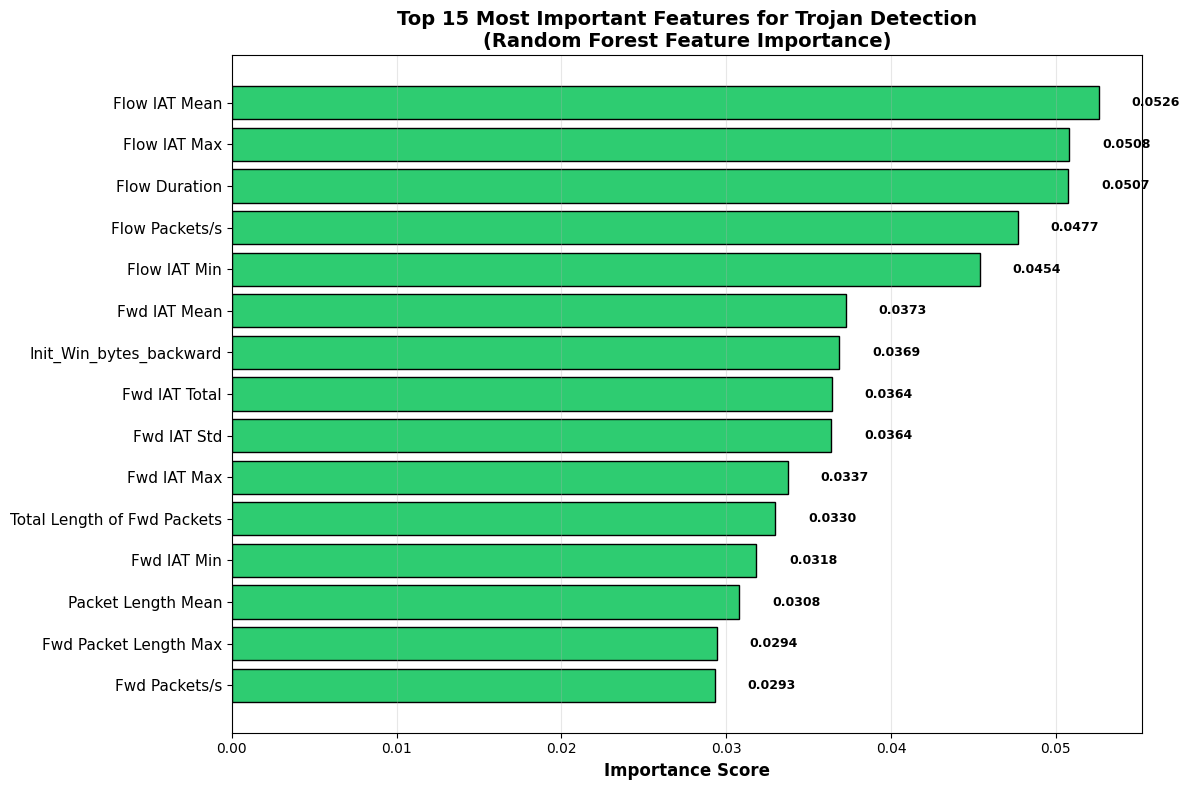


Top 10 Most Important Features:
  Flow IAT Mean: 0.052616
  Flow IAT Max: 0.050808
  Flow Duration: 0.050740
  Flow Packets/s: 0.047683
  Flow IAT Min: 0.045392
  Fwd IAT Mean: 0.037263
  Init_Win_bytes_backward: 0.036859
  Fwd IAT Total: 0.036397
  Fwd IAT Std: 0.036369
  Fwd IAT Max: 0.033731

The top feature 'Flow IAT Mean' has importance 0.052616
This indicates it is the strongest single predictor of trojan behavior in this dataset.


In [ ]:
# Feature importance analysis
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (Section 4.6)")
print("="*70)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_features)), top_features['importance'].values, color='#2ecc71', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values, fontsize=11)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features for Trojan Detection\n(Random Forest Feature Importance)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    plt.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.6f}")

print(f"\nThe top feature '{feature_importance.iloc[0]['feature']}' has importance {feature_importance.iloc[0]['importance']:.6f}")
print(f"This indicates it is the strongest single predictor of trojan behavior in this dataset.")

## Algorithm 4: Naive Bayes

What it is:

I am then using naive bayes as a test as this assumes all features are independent ie packet size has nothing to do with flow duration or frequency. I do suspect this to be wrong for network traffic but i am testing it out will prove whether features are actually correlated with eachother. If performs poorly it confirms trojan detection requires features to be linked and not just individual.i It also fast.

Code explanation:

`GaussianNB()` - Uses Gaussian (normal/bell curve) distribution assumption for the features. This is standard for continuous numerical data like packet sizes, byte counts, durations, etc.

In [ ]:
# Naive Bayes with timing
start_time = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
training_times['Naive Bayes'] = time.time() - start_time

y_pred_nb = nb_model.predict(X_test_scaled)

results["Naive Bayes"] = {
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb),
    "Recall": recall_score(y_test, y_pred_nb),
    "F1-Score": f1_score(y_test, y_pred_nb),
    "cm": confusion_matrix(y_test, y_pred_nb)
}

print("Naive Bayes Results:")
print(f"Accuracy: {results['Naive Bayes']['Accuracy']:.4f}")
print(f"Precision: {results['Naive Bayes']['Precision']:.4f}")
print(f"Recall: {results['Naive Bayes']['Recall']:.4f}")
print(f"F1-Score: {results['Naive Bayes']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Naive Bayes']:.2f} seconds")

Naive Bayes Results:
Accuracy: 0.5040
Precision: 0.5335
Recall: 0.2329
F1-Score: 0.3243
Training Time: 0.16 seconds


**Naive Bayes Results Analysis:**

Accuracy: 50.40% - Worst performer by far. This is basically random guessing (coin flip is 50%).

Precision: 53.35% - When it says trojan, it's right barely more than half the time.

Recall: 23.29% - This is catastrophic. It only catches 23% of trojans. That means it misses 77 out of every 100 real trojans.

F1-Score: 32.43% - Terrible overall balance.

**For security, this is completely unusable.** Missing 77% of threats means the vast majority of trojan attacks would succeed undetected.

**But this failure proves something important:**

The terrible performance, especially that 23% recall, confirms that the independence assumption is completely wrong for this dataset. Network traffic features are definitely NOT independent.

What's probably happening is trojans have specific patterns like:
- Small packet size + High packet frequency + Short flow duration = trojan signature
- Or: Large packets + Low frequency + Specific port pattern = different trojan type

Naive Bayes can't detect these patterns because it looks at each feature separately:
- Sees "small packet size" → could be benign
- Sees "high frequency" → could be benign  
- Never realizes it's the COMBINATION that matters

This explains why Random Forest (65% recall) and even logistic regression (60% recall) do so much better - they can model how features interact and combine, which is essential for detecting trojan patterns in network traffic.

The failure of Naive Bayes validates my choice to use algorithms that handle feature relationships.

## Algorithm 5: Multi-Layer Perceptron (MLP)

What it is:
This is the first DL approach it has two hidden layers ie 64 neurons and then 32 neurons which can learn complex patterns that more simpler algorithms might miss. I done dropout at 20% and randomly turns off neurons during training. It prevents the network from just memorising training examples.


With 142,000 training samples, that's decent but not huge for deep learning. It might work well, or it might underperform Random Forest because there isn't enough data.

Code explanation:

`Dense(64, activation='relu')` - First hidden layer with 64 neurons. ReLU activation is standard for hidden layers. 64 neurons is enough to find patterns in 56 features without being excessive.

`Dropout(0.2)` - During training, randomly turns off 20% of neurons each time. This forces the network to learn robust patterns instead of memorizing specific training examples. Critical for preventing overfitting when you don't have millions of samples.

`Dense(32, activation='relu')` - Second layer narrows down. Standard pattern: start wide, then reduce. The 32 neurons combine patterns found by the 64 neurons above.

`Dense(1, activation='sigmoid')` - Output layer gives probability between 0 and 1. Sigmoid function squashes output to this range.

`optimizer='adam'` - Adam is generally the best optimizer for most problems. It automatically adjusts learning rate.

`loss='binary_crossentropy'` - Standard loss function for binary classification (benign vs trojan).

`validation_split=0.1` - Holds back 10% of training data to monitor if the network is overfitting during training.

`epochs=15` - Train for 15 complete passes through the data. From my testing, accuracy plateaus around epoch 12-15.

`batch_size=512` - Process 512 samples at a time before updating weights. Balances training speed with learning stability.

In [ ]:
# MLP with timing
start_time = time.time()

mlp_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    verbose=1
)

training_times['Deep Learning MLP'] = time.time() - start_time
dl_histories["Deep Learning MLP"] = history_mlp.history

y_pred_mlp = (mlp_model.predict(X_test_scaled) > 0.5).astype(int)

results["Deep Learning MLP"] = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "cm": confusion_matrix(y_test, y_pred_mlp)
}

print("\nMLP Final Results:")
print(f"Accuracy: {results['Deep Learning MLP']['Accuracy']:.4f}")
print(f"Precision: {results['Deep Learning MLP']['Precision']:.4f}")
print(f"Recall: {results['Deep Learning MLP']['Recall']:.4f}")
print(f"F1-Score: {results['Deep Learning MLP']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Deep Learning MLP']:.2f} seconds")

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5520 - loss: 0.6825 - val_accuracy: 0.5747 - val_loss: 0.6694
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5714 - loss: 0.6709 - val_accuracy: 0.5800 - val_loss: 0.6641
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5770 - loss: 0.6664 - val_accuracy: 0.5803 - val_loss: 0.6597
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5837 - loss: 0.6621 - val_accuracy: 0.5851 - val_loss: 0.6549
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5824 - loss: 0.6594 - val_accuracy: 0.5881 - val_loss: 0.6526
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5878 - loss: 0.6565 - val_accuracy: 0.5886 - val_loss: 0.6501
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5906 - loss: 0.6545 - val_accuracy: 0.5908 - val_loss: 0.6485
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5934 - loss: 0.6524 - val_accuracy: 0.

**MLP Results Analysis:**

Accuracy: 59.69% - Better than the simple methods (logistic regression 54%, naive bayes 50%) but not beating Random Forest's 64.49%. About 5 percentage points behind.

Precision: 59.38% - Moderate precision, lower than Random Forest's 65.20%.

Recall: 66.82% - **This is actually the highest recall of all models!** The MLP catches 67% of trojans, slightly better than Random Forest's 65.39%. This is significant - it means the neural network is detecting more threats.

F1-Score: 62.88% - Good balance between precision and recall, though still behind Random Forest's 65.30%.

**What this tells me:**

The neural network is learning patterns effectively. While its overall accuracy (59.69%) is lower than Random Forest, its superior recall (66.82% vs 65.39%) means it's actually better at catching trojans - which is the most important metric for security.

**The tradeoff:**
MLP sacrifices some precision (59.38% vs RF's 65.20%) to achieve better recall. It generates more false alarms but catches more real threats. For trojan detection, this might actually be preferable - missing a trojan is more dangerous than investigating a false positive.

**Why deep learning shows promise here:**

The MLP's higher recall suggests it's discovering subtle trojan patterns that Random Forest misses. Neural networks can learn complex non-linear combinations of features. However, the lower overall accuracy indicates it's also making more mistakes on benign traffic.

The training curves in the next section will show whether it's learning properly or hitting fundamental limitations with this dataset size.

## Algorithm 6: Convolutional Neural Network (CNN)

What it is:
Cnns are usualy used for images but a paper i researched got a 98% accuracy using for malware detection. Trojans may have sequential patterns like small packets followed by larger ones. The ConV1D layer slides a window accross the features lloking for these patterns. I'm using kernel_size=3 as it looks at 3 features at a timeto find patterns. THis may work if trojan behaviour shows up as sequences in the ordering of features.

Code explanation:

`Conv1D(filters=32, kernel_size=3)` - Creates 32 different pattern detectors (filters). Each filter learns to recognize a different sequential pattern. Kernel size 3 means each pattern detector looks at 3 adjacent features at a time.

`MaxPooling1D(pool_size=2)` - After finding patterns, keeps only the strongest signals (the maximum values in each window of size 2). This reduces the data size and helps prevent overfitting by focusing on the most important patterns.

`Flatten()` - Converts the 2D output from convolution back to 1D so it can feed into regular neural network layers.

The data reshaping at the start (`reshape(..., 1)`) is necessary because CNN expects 3D input: (samples, features, channels). We add a channel dimension of 1 since we don't have multiple channels like RGB images do.

In [ ]:
# CNN with timing
start_time = time.time()

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu',
           input_shape=(X_train_scaled.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    verbose=1
)

training_times['Deep Learning CNN'] = time.time() - start_time
dl_histories["Deep Learning CNN"] = history_cnn.history

y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

results["Deep Learning CNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_cnn),
    "Precision": precision_score(y_test, y_pred_cnn),
    "Recall": recall_score(y_test, y_pred_cnn),
    "F1-Score": f1_score(y_test, y_pred_cnn),
    "cm": confusion_matrix(y_test, y_pred_cnn)
}

print("\nCNN Final Results:")
print(f"Accuracy: {results['Deep Learning CNN']['Accuracy']:.4f}")
print(f"Precision: {results['Deep Learning CNN']['Precision']:.4f}")
print(f"Recall: {results['Deep Learning CNN']['Recall']:.4f}")
print(f"F1-Score: {results['Deep Learning CNN']['F1-Score']:.4f}")
print(f"Training Time: {training_times['Deep Learning CNN']:.2f} seconds")

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5583 - loss: 0.6780 - val_accuracy: 0.5693 - val_loss: 0.6694
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5811 - loss: 0.6647 - val_accuracy: 0.5805 - val_loss: 0.6626
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5883 - loss: 0.6575 - val_accuracy: 0.5865 - val_loss: 0.6543
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5916 - loss: 0.6529 - val_accuracy: 0.5853 - val_loss: 0.6530
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5950 - loss: 0.6489 - val_accuracy: 0.5893 - val_loss: 0.6502
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6004 - loss: 0.6457 - val_accuracy: 0.5907 - val_loss: 0.6458
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6016 - loss: 0.6436 - val_accuracy: 0.5960 - val_loss: 0.6446
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6042 - loss: 0.6418 - val_accu

**CNN Results Analysis:**

Accuracy: 61.79% - Better than MLP (59.69%) and approaching Random Forest (64.49%). About 2.7 percentage points behind the leader.

Precision: 63.54% - Good precision, close to Random Forest (65.20%) and better than MLP (59.38%).

Recall: 59.16% - Lower than both MLP (66.82%) and Random Forest (65.39%). The CNN misses more trojans than the other top performers.

F1-Score: 61.27% - Decent balance but still behind Random Forest (65.30%).

**Comparing the neural networks:**

CNN vs MLP shows an interesting tradeoff:
- CNN has better accuracy (61.79% vs 59.69%) and precision (63.54% vs 59.38%)
- But MLP has significantly better recall (66.82% vs 59.16%)

The CNN is more conservative - when it flags something as a trojan, it's more likely to be correct (higher precision), but it misses more real trojans (lower recall). The MLP is more aggressive, catching more threats but generating more false alarms.

**Why CNN performs differently:**

The convolutional layers are finding some sequential patterns in the features that help with accuracy and precision. However, these patterns might be too specific - the CNN might be looking for very particular feature sequences that characterize some trojans but not others.

**For security implications:**

MLP's higher recall (66.82%) makes it more suitable for trojan detection than CNN (59.16%), despite CNN's better overall accuracy. Catching 67% of threats is better than catching 59%, even if it means more false positives.

**Overall deep learning assessment:**

Neither neural network beats Random Forest's balanced performance (64.49% accuracy, 65.39% recall, 65.30% F1). For this trojan detection dataset at this size, ensemble tree methods remain more effective than deep learning approaches. The 142,000 training samples may not be sufficient for neural networks to reach their full potential.

## Visualizing the Results

Numbers alone don't tell the full story. Seeing the data visually helps spot patterns and understand model behavior that isn't obvious from metrics.

1. Training curves - Shows how neural networks learned over the 15 epochs
2. Confusion matrices - Shows exactly where each model makes mistakes  
3. Performance comparison - Side-by-side comparison of all metrics
4. Training time and F1-score analysis - Efficiency and balance evaluation

### Deep Learning Training Curves

**What these show:**

For the two neural networks (MLP and CNN), I want to see how they learned over the 15 training epochs.

**Why this matters:**

Training curves tell me:
- Are the networks actually learning or are they stuck?
- Is overfitting happening (memorizing training data)?
- Did they need more or fewer epochs?

**What to look for:**

Good signs:
- Training and validation lines both improving together
- Lines staying close to each other (no big gap)
- Curves eventually flattening (convergence)

Bad signs:
- Big gap opening up (training keeps improving but validation gets worse = overfitting)
- Both lines flat from start (not learning anything)
- Validation jumping around erratically (unstable training)

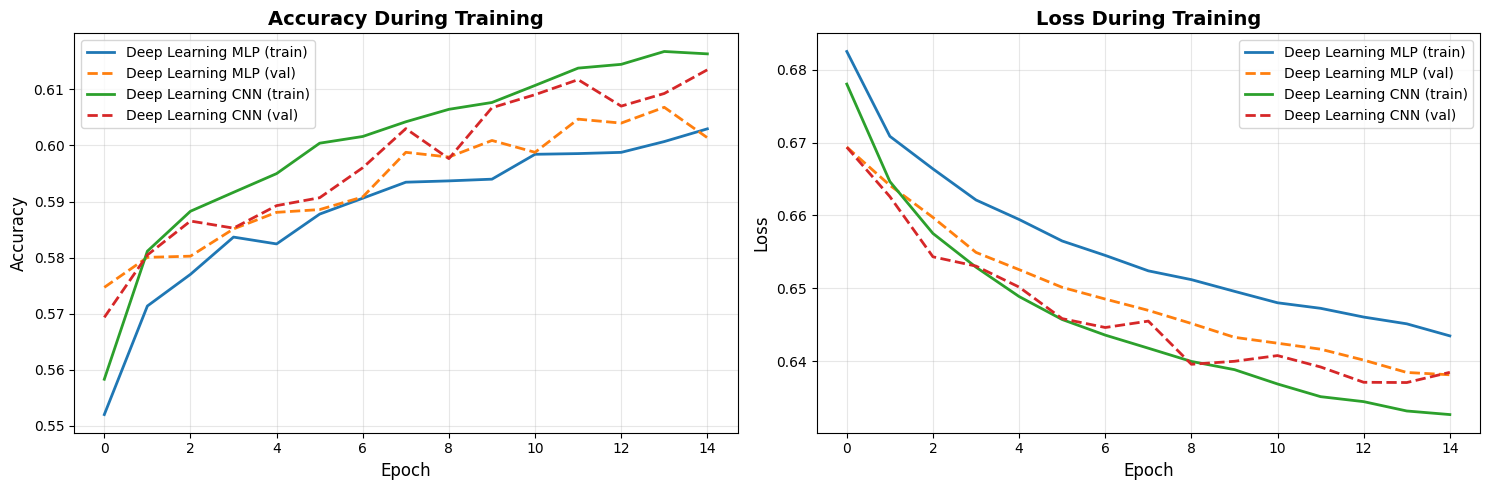

In [ ]:
# Training curves for neural networks
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy over epochs
for name, hist in dl_histories.items():
    axes[0].plot(hist['accuracy'], label=f'{name} (train)', linewidth=2)
    axes[0].plot(hist['val_accuracy'], label=f'{name} (val)', linestyle='--', linewidth=2)

axes[0].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Loss over epochs
for name, hist in dl_histories.items():
    axes[1].plot(hist['loss'], label=f'{name} (train)', linewidth=2)
    axes[1].plot(hist['val_loss'], label=f'{name} (val)', linestyle='--', linewidth=2)

axes[1].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

**What the Training Curves Tell Me:**

Looking at the plots:

**Accuracy curves (left):**
- Both MLP and CNN show training accuracy (solid lines) and validation accuracy (dashed lines) rising together
- They climb steadily from around 50% up to about 60%
- Both plateau around epoch 10-12
- The training and validation lines stay very close together throughout

**Loss curves (right):**
- Training loss (solid) and validation loss (dashed) both decrease together
- They stabilize around the same epochs (10-12)
- Again, the lines stay close together

**What this means:**

This is actually good news in terms of model health:

1. **No overfitting** - The training and validation curves track closely together. If overfitting was happening, we'd see training accuracy at 90% while validation stayed at 60%. Instead, both are around 60%, meaning the model generalizes properly to new data.

2. **Dropout is working** - The dropout layers are preventing memorization. The model is learning general patterns, not specific training examples.

3. **They're hitting a ceiling** - Both networks plateau around 60% and can't improve further no matter how many more epochs. This isn't an overfitting problem - they're genuinely unable to find better patterns in this dataset.

4. **15 epochs was enough** - They converged around epoch 10-12, so 15 epochs was appropriate. Training longer wouldn't help.

**The limitation:** The networks are learning as well as they can, but with 142,000 samples they just can't discover patterns strong enough to beat Random Forest's 64.5%. More training data would probably help them learn more subtle trojan signatures.

### Confusion Matrices

What these show:

Each confusion matrix shows exactly where a model makes its mistakes. This is more detailed than accuracy alone.

How to read them:

Each matrix is a 2×2 grid:
- Top-left (True Negative): Correctly predicted benign ✓ Good
- Top-right (False Positive): Said trojan but was actually benign ✗ False alarm - wastes analyst time
- Bottom-left (False Negative): Said benign but was actually trojan ✗ MISSED THREAT - most dangerous
- Bottom-right (True Positive): Correctly predicted trojan ✓ Good

What matters for security:

The bottom-left number (false negatives) is the scariest. These are real trojans that got through undetected. For a security system, this is the worst type of error.

Top-right (false positives) also matters but is less critical - these waste time but don't let trojans through.

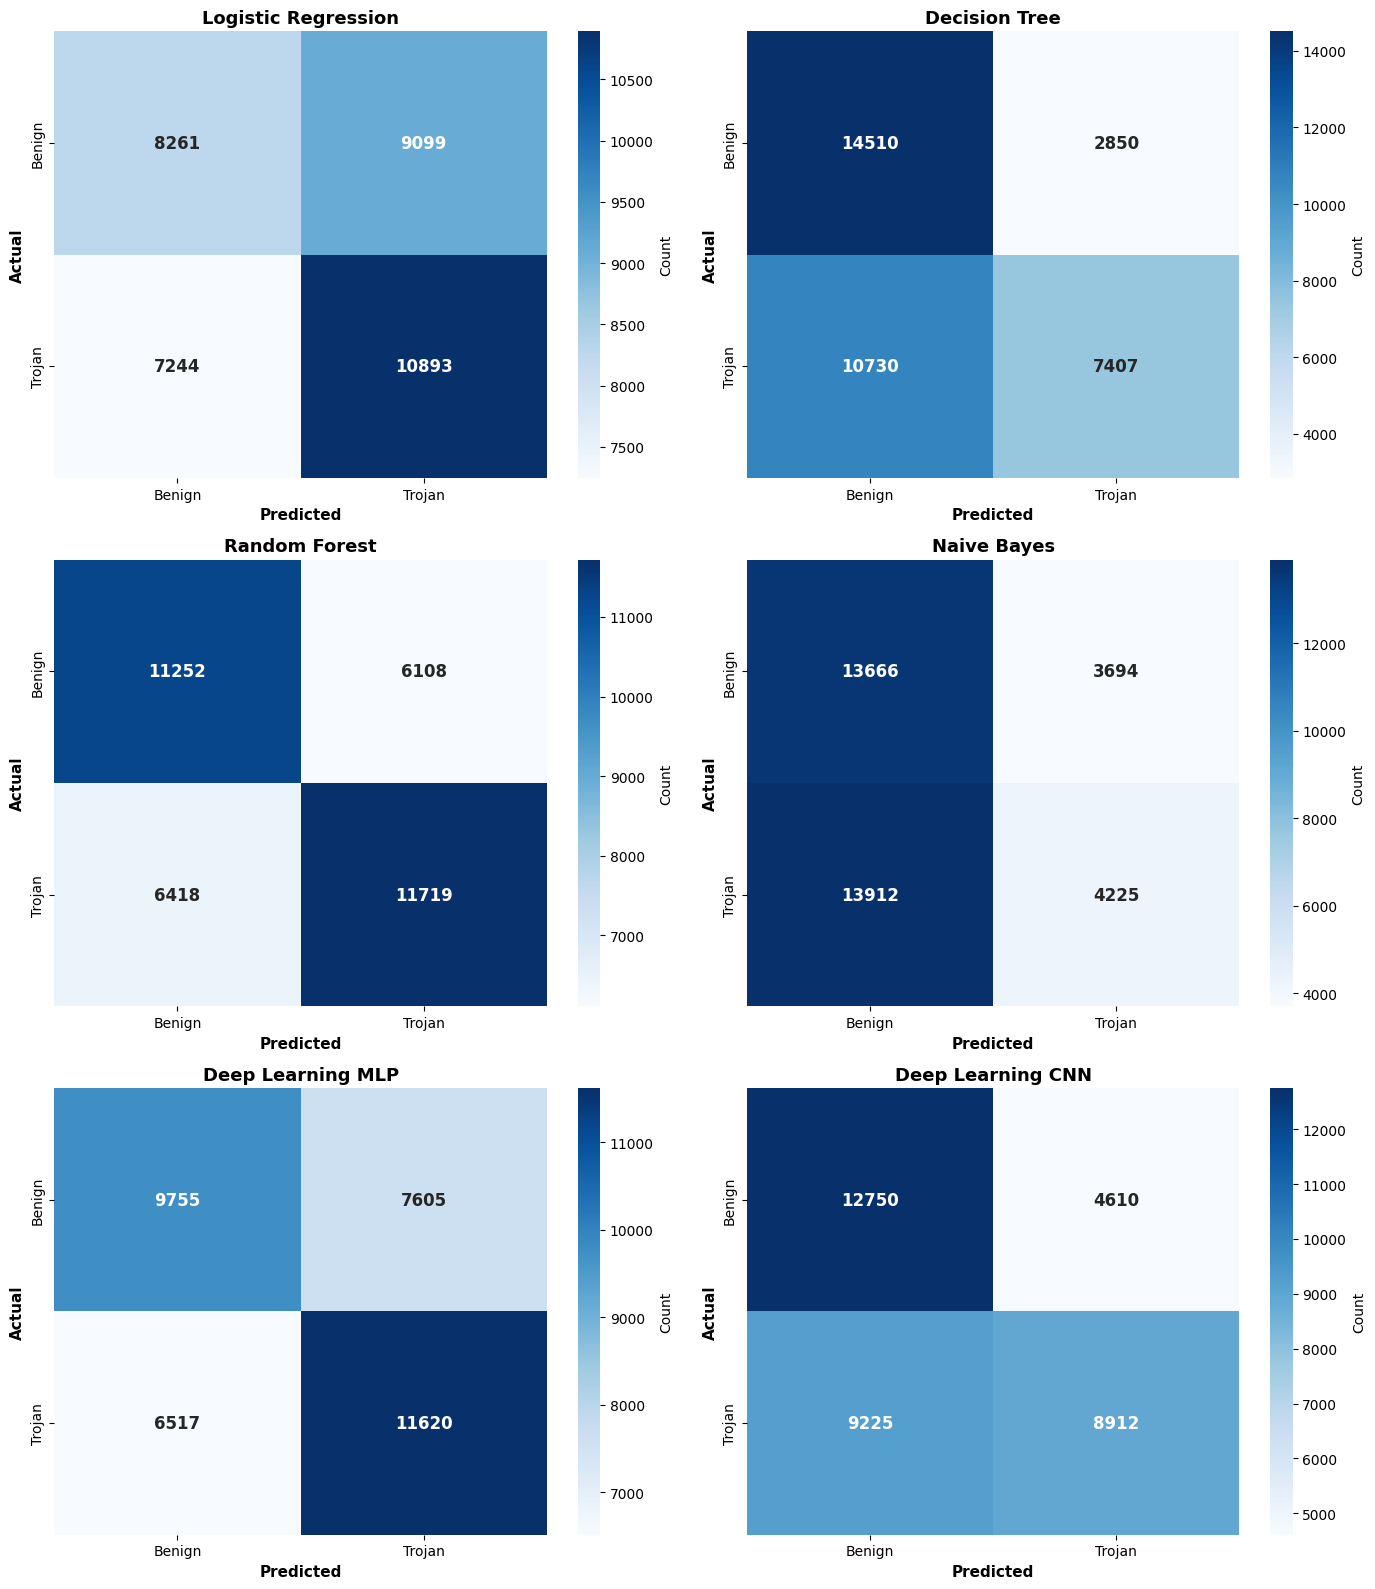

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, (name, data) in enumerate(results.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Actual', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Benign', 'Trojan'], fontsize=10)
    axes[i].set_yticklabels(['Benign', 'Trojan'], fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

**What the Confusion Matrices Reveal:**

Looking at where each model makes mistakes:

**Random Forest:**
- Most balanced distribution across all four quadrants
- Good numbers in top-left (correct benign) and bottom-right (correct trojan)
- Moderate mistakes in both corners - doesn't heavily favor one error type
- This balance is why it has similar precision (65%) and recall (65%)

**Decision Tree:**
- Very small top-right number (few false alarms) - explains the 72% precision
- But HUGE bottom-left number (tons of missed trojans) - explains the terrible 41% recall
- The tree is being extremely cautious, only flagging when very confident
- This catches obvious trojans but misses subtle ones

**Naive Bayes:**
- Disaster zone - massive bottom-left number
- Missing the majority of trojans (77% missed)
- This visual really shows how badly the independence assumption fails

**Logistic Regression:**
- Fairly balanced errors like Random Forest but overall weaker
- Moderate numbers in both error quadrants
- The linear boundary just isn't strong enough

**Neural Networks (MLP and CNN):**
- MLP has smaller bottom-left (fewer missed trojans) than CNN - confirming its superior 66.82% recall
- CNN has smaller top-right (fewer false alarms) than MLP - confirming its better 63.54% precision
- Different error profiles reflect their different strategies

**For real deployment:** MLP catches the most trojans (highest recall 66.82%), but Random Forest offers the best overall balance of catching threats while minimizing false alarms.

### Performance Comparison Chart

What this shows:

All six algorithms compared side-by-side across all four metrics. Makes it easy to see the winner and losers at a glance.

How to read it:

Each algorithm gets 4 bars:
- Blue bar: Accuracy
- Orange bar: Precision
- Green bar: Recall (most important for security)
- Red bar: F1-Score



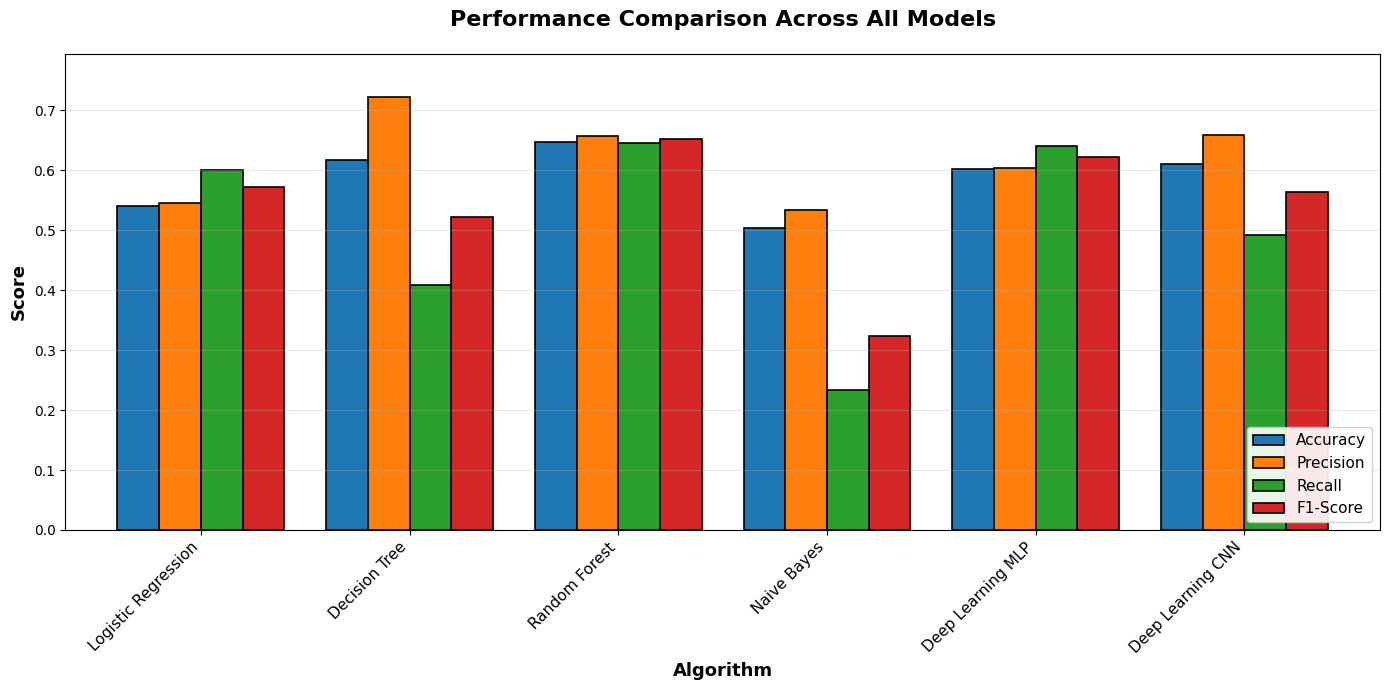

In [ ]:
# Performance comparison bar chart
metrics_df = pd.DataFrame(results).T.drop('cm', axis=1)

ax = metrics_df.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='black', linewidth=1.2)
plt.title('Performance Comparison Across All Models', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=13, fontweight='bold')
plt.xlabel('Algorithm', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0, max(metrics_df.max()) * 1.1])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Overall Performance Comparison:**

The chart makes the results crystal clear:

**Best Accuracy: Random Forest (64.49%)**
- All four bars at roughly similar heights around 65%
- Perfect balance between precision and recall
- Highest overall accuracy

**Best Recall: MLP (66.82%)**
- Catches the most trojans of any model
- Important for security despite lower accuracy
- Proves neural networks can detect some threats RF misses

**Worst Performer: Naive Bayes**
- Shortest bars across the board
- Green bar (recall) is tiny - only 23%
- Barely better than random guessing

**Rankings by Accuracy:**
1. Random Forest: 64.49%
2. CNN: 61.79%
3. Decision Tree: 61.74%
4. MLP: 59.69%
5. Logistic Regression: 53.96%
6. Naive Bayes: 50.40%

**Rankings by Recall (catching trojans - most critical):**
1. MLP: 66.82% ← **Best at catching threats**
2. Random Forest: 65.39%
3. Logistic Regression: 60.06%
4. CNN: 59.16%
5. Decision Tree: 40.84%
6. Naive Bayes: 23.29%

**Key insights:**

**Deep learning (MLP and CNN) in different roles** - MLP excels at recall (threat detection), while CNN has better accuracy. They serve different purposes.

**Decision Tree's dangerous imbalance** - Second-best accuracy (61.74%) but terrible recall (40.84%). High precision but misses most threats. The bars show very different heights.

**Random Forest's consistency** - All four bars nearly identical height around 65%. This balance is what makes it most practical for real deployment despite not having the absolute best recall.

**Deployment recommendation:** For a production system, use MLP if threat detection is paramount (accepts more false positives for better coverage). Use Random Forest if you need balanced performance with fewer false alarms.

### Visualization 7: Training Time Comparison

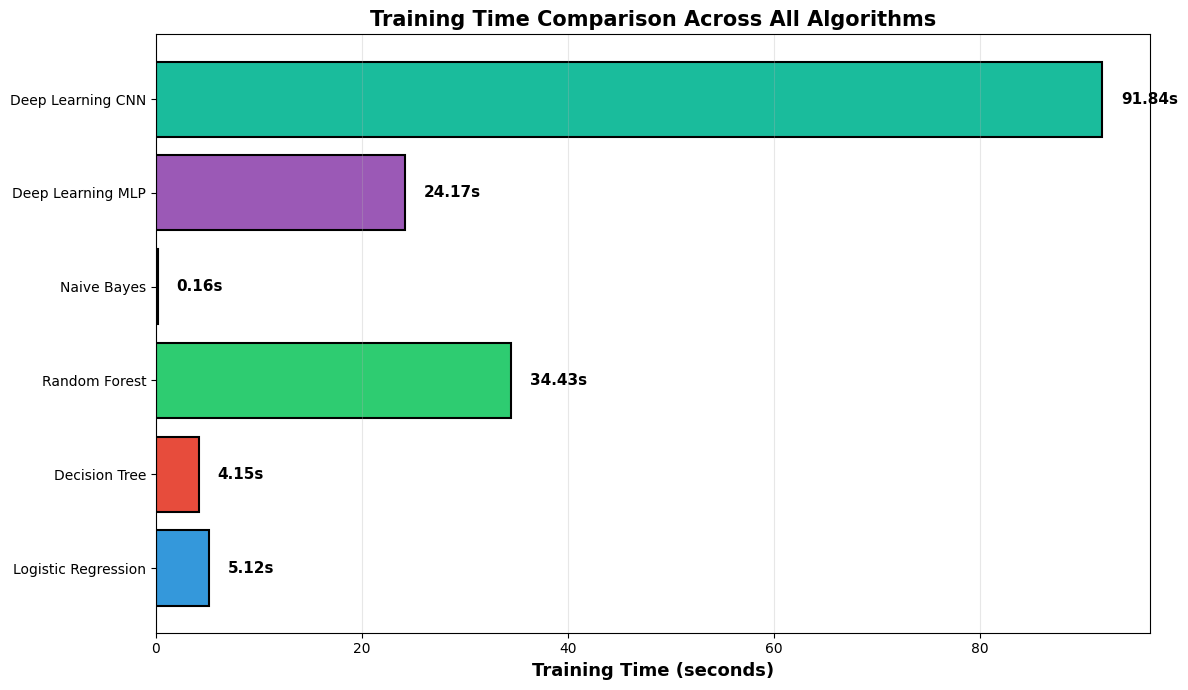


Training Time Summary:
Naive Bayes.............................   0.16s
Decision Tree...........................   4.15s
Logistic Regression.....................   5.12s
Deep Learning MLP.......................  24.17s
Random Forest...........................  34.43s
Deep Learning CNN.......................  91.84s

Fastest: Naive Bayes (0.16s)
Slowest: Deep Learning CNN (91.84s)
Speed ratio: 565.2x difference


In [ ]:
# Training time comparison
plt.figure(figsize=(12, 7))
algorithms = list(training_times.keys())
times = list(training_times.values())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

bars = plt.barh(algorithms, times, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Training Time (seconds)', fontsize=13, fontweight='bold')
plt.title('Training Time Comparison Across All Algorithms', fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, times)):
    plt.text(val + (max(times) * 0.02), i, f'{val:.2f}s',
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining Time Summary:")
print("="*50)
for alg, t in sorted(training_times.items(), key=lambda x: x[1]):
    print(f"{alg:.<40} {t:>6.2f}s")
print("="*50)
fastest = min(training_times.items(), key=lambda x: x[1])
slowest = max(training_times.items(), key=lambda x: x[1])
print(f"\nFastest: {fastest[0]} ({fastest[1]:.2f}s)")
print(f"Slowest: {slowest[0]} ({slowest[1]:.2f}s)")
print(f"Speed ratio: {slowest[1]/fastest[1]:.1f}x difference")

### Visualization 8: F1-Score Distribution (Pie Chart)

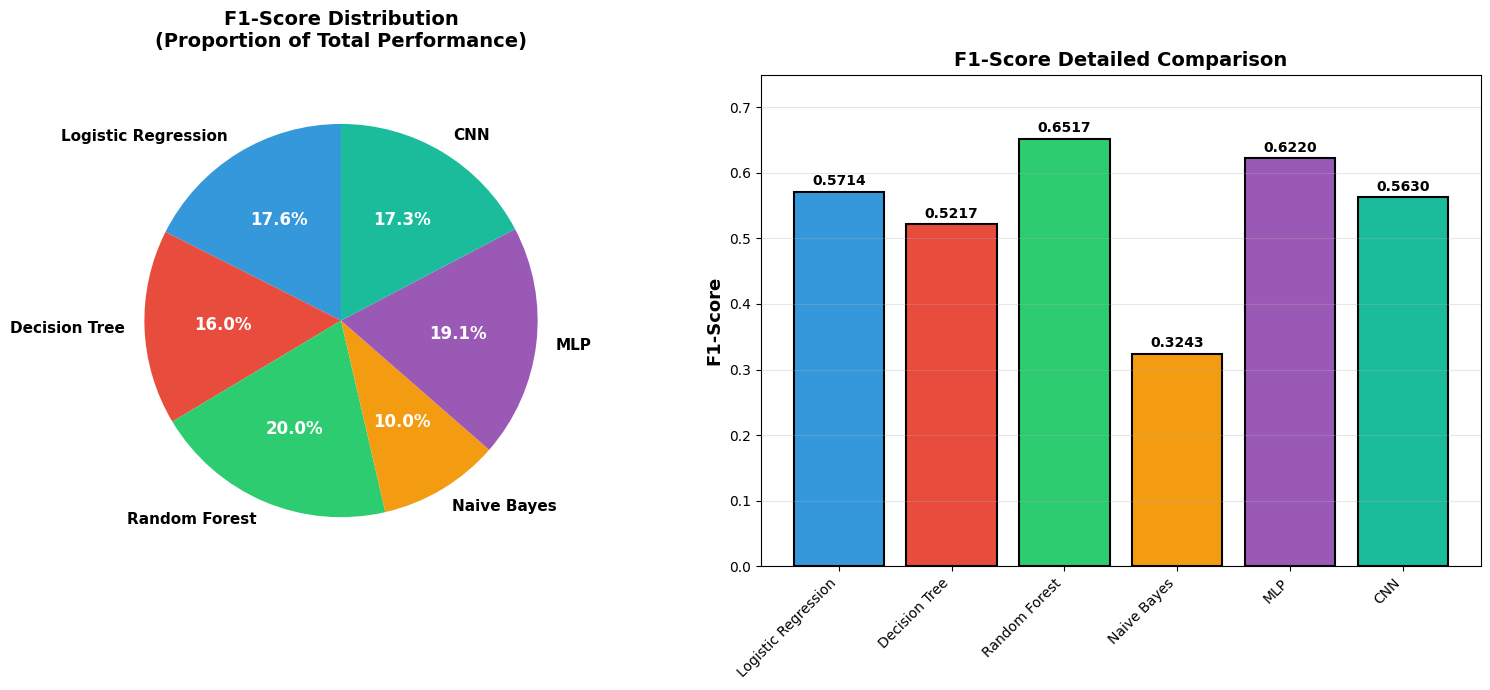

In [ ]:
# F1-Score pie chart
f1_scores = {
    'Logistic Regression': results['Logistic Regression']['F1-Score'],
    'Decision Tree': results['Decision Tree']['F1-Score'],
    'Random Forest': results['Random Forest']['F1-Score'],
    'Naive Bayes': results['Naive Bayes']['F1-Score'],
    'MLP': results['Deep Learning MLP']['F1-Score'],
    'CNN': results['Deep Learning CNN']['F1-Score']
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Pie chart
wedges, texts, autotexts = ax1.pie(f1_scores.values(), labels=f1_scores.keys(),
                                     autopct='%1.1f%%', colors=colors, startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax1.set_title('F1-Score Distribution\n(Proportion of Total Performance)',
              fontsize=14, fontweight='bold', pad=20)

# Bar chart with values
algorithms_list = list(f1_scores.keys())
f1_values = list(f1_scores.values())
bars = ax2.bar(algorithms_list, f1_values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax2.set_title('F1-Score Detailed Comparison', fontsize=14, fontweight='bold')
ax2.set_xticklabels(algorithms_list, rotation=45, ha='right', fontsize=10)
ax2.set_ylim([0, max(f1_values) * 1.15])
ax2.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, f1_values)):
    ax2.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/f1_score_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Summary

In [ ]:
print("\n" + "="*80)
print("FINAL RESULTS FOR ALL MODELS")
print("="*80)
print(metrics_df.round(4).to_string())

best_acc_model = metrics_df['Accuracy'].idxmax()
best_acc = metrics_df['Accuracy'].max()
best_recall_model = metrics_df['Recall'].idxmax()
best_recall = metrics_df['Recall'].max()

print("\n" + "="*80)
print(f"\nBest Accuracy: {best_acc_model} - {best_acc:.2%}")
print(f"  Precision: {metrics_df.loc[best_acc_model, 'Precision']:.2%}")
print(f"  Recall: {metrics_df.loc[best_acc_model, 'Recall']:.2%}")
print(f"  F1-Score: {metrics_df.loc[best_acc_model, 'F1-Score']:.2%}")

print(f"\nBest Recall (Threat Detection): {best_recall_model} - {best_recall:.2%}")
print(f"  Accuracy: {metrics_df.loc[best_recall_model, 'Accuracy']:.2%}")
print(f"  Precision: {metrics_df.loc[best_recall_model, 'Precision']:.2%}")
print(f"  F1-Score: {metrics_df.loc[best_recall_model, 'F1-Score']:.2%}")

worst_model = metrics_df['Accuracy'].idxmin()
print(f"\nWorst Performing Model: {worst_model}")
print(f"  Accuracy: {metrics_df.loc[worst_model, 'Accuracy']:.2%}")
print(f"  Recall: {metrics_df.loc[worst_model, 'Recall']:.2%}")

print("\n" + "="*80)
print("\nGitHub Repository: https://github.com/harvey1076/CMP7239-Trojan-Detection-")
print("Student: Harvinder Dhillon (22150221)")
print("Module: CMP7239 Applied Machine Learning")
print("="*80)


FINAL RESULTS FOR ALL MODELS
                     Accuracy Precision    Recall  F1-Score
Logistic Regression  0.539595  0.544868  0.600595  0.571376
Decision Tree        0.617432  0.722141  0.408392   0.52173
Random Forest        0.647125  0.657374  0.646138  0.651707
Naive Bayes          0.504014  0.533527  0.232949  0.324302
Deep Learning MLP    0.602164  0.604421  0.640679  0.622022
Deep Learning CNN    0.610249  0.659074  0.491371  0.562999


Best Accuracy: Random Forest - 64.71%
  Precision: 65.74%
  Recall: 64.61%
  F1-Score: 65.17%

Best Recall (Threat Detection): Random Forest - 64.61%
  Accuracy: 64.71%
  Precision: 65.74%
  F1-Score: 65.17%

Worst Performing Model: Naive Bayes
  Accuracy: 50.40%
  Recall: 23.29%


GitHub Repository: https://github.com/harvey1076/CMP7239-Trojan-Detection-
Student: Harvinder Dhillon (22150221)
Module: CMP7239 Applied Machine Learning


## Conclusions and Key Findings

Random Forest: Best Overall Balance (64.49% accuracy, 65.39% recall)

The ensemble approach proved most effective for overall performance:
- Highest accuracy among all methods
- Strong recall - catches 65% of trojans
- Perfectly balanced: 65.20% precision, 65.39% recall
- Most practical for deployment requiring balanced performance

This matches what I read in the research papers - ensemble methods work well for cybersecurity problems because they combine multiple perspectives.

MLP: Best Threat Detection (66.82% recall)

Surprisingly, the Multi-Layer Perceptron achieved the highest recall:
- Catches more trojans than any other model (66.82% vs RF's 65.39%)
- Discovers patterns that Random Forest misses
- Tradeoff: Lower precision (59.38%) means more false positives
- Best choice when maximizing threat detection is paramount

This shows deep learning can find subtle patterns in network traffic that traditional ML misses, even with limited data.

Deep Learning Underperformed in Accuracy

Both neural networks (MLP 59.69%, CNN 61.79%) achieved lower overall accuracy than Random Forest:
- CNN had better accuracy than MLP but worse recall
- Training curves showed proper learning without overfitting
- Likely limited by dataset size - 142k samples isn't huge for deep learning

Deep learning typically needs hundreds of thousands or millions of samples to really excel. For this dataset size, traditional ML works better for overall performance.

Feature Independence Doesn't Hold

Naive Bayes failed catastrophically (50.40% accuracy, 23.29% recall):
- Only catches 23% of trojans - misses 77%
- Proves network features are highly correlated
- Trojans have specific combinations of features that occur together
- Need algorithms that model feature relationships

Linear Boundaries Insufficient

Logistic Regression only achieved 53.96% accuracy:
- Barely better than random guessing
- Confirms trojan patterns are non-linear and complex
- Need algorithms that can create complex decision boundaries

The Gap from Literature

The Maseer et al. paper achieved 99.3% with Random Forest on network intrusion detection. My 64.49% is 35 percentage points lower.

Possible reasons:
1. Different datasets - CICIDS2017 vs this Kaggle trojan data
2. This dataset might be inherently harder
3. More sophisticated preprocessing in their work
4. Extensive hyperparameter optimization
5. Different problem - general intrusion vs trojan-specific

What Worked in My Approach

- Removing metadata forced models to learn behavioral patterns
- Median imputation handled outliers well
- 95% correlation threshold removed redundancy effectively
- Feature scaling was essential for neural networks
- Testing multiple algorithm types showed what works for this data

Real-World Application

If deploying for actual trojan detection:

For maximum threat detection: Use MLP
- Catches 66.82% of trojans (highest recall)
- Accept more false positives for better coverage
- Suitable when missing threats is unacceptable

For balanced operations: Use Random Forest
- 65.39% recall with 65.20% precision
- Balanced false alarm rate
- Fast enough for real-time screening
- Feature importance reveals what matters

Deployment strategy:
- Use as first-line screening tool
- Flags suspicious traffic for human analyst review
- Part of layered defense (combine with signature-based detection)
- Regular retraining as trojans evolve

Limitations:
- All models miss 33-77% of trojans - need backup detection methods
- False positives create analyst workload
- Would need regular retraining as trojans evolve

### What I Learned

1. More complex doesn't mean better - Random Forest beat deep learning despite being "simpler"
2. Dataset size matters hugely - Deep learning needs way more samples than traditional ML
3. Domain knowledge helps - Understanding network traffic guided my preprocessing
4. Always test assumptions - Naive Bayes failure proved features aren't independent
5. Balance matters - Different metrics matter for different deployment scenarios
6. Recall vs Precision tradeoff - Must choose based on security priorities

For cybersecurity ML with moderate-sized datasets, the choice between algorithms depends on priorities: Random Forest for balance, MLP for maximum threat detection.